# Comparison Of Exploratory Analysis Of Datasets

In [1]:
import os
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

def safe_listdir(path):
    return [x for x in os.listdir(path) if not x.startswith(".")]

def count_csv_rows_fast(path):
    # conta linhas sem carregar para memória (subtrai header)
    with open(path, "rb") as f:
        n = sum(1 for _ in f)
    return max(0, n - 1)

def count_txt_rows_fast(path):
    with open(path, "rb") as f:
        n = sum(1 for _ in f)
    return n

def infer_sampling_rate_from_timestamp(ts):
    # ts: pandas Series em segundos
    ts = pd.to_numeric(ts, errors="coerce").dropna()
    if len(ts) < 5:
        return np.nan
    d = ts.diff().dropna()
    d = d[(d > 0) & np.isfinite(d)]
    if len(d) < 5:
        return np.nan
    dt = d.median()
    if dt <= 0:
        return np.nan
    return 1.0 / dt

def add_mag_features(df, acc_cols, gyro_cols=None, prefix=""):
    out = df.copy()
    ax, ay, az = acc_cols
    out[f"{prefix}acc_mag"] = np.sqrt(out[ax]**2 + out[ay]**2 + out[az]**2)
    if gyro_cols is not None:
        gx, gy, gz = gyro_cols
        out[f"{prefix}gyro_mag"] = np.sqrt(out[gx]**2 + out[gy]**2 + out[gz]**2)
    return out

In [2]:
kfall_sensor_path = "Kfall/sensor_data_new"
kfall_subject_dirs = [s for s in safe_listdir(kfall_sensor_path) if os.path.isdir(os.path.join(kfall_sensor_path, s))]

kfall_rows = []
for subj_dir in kfall_subject_dirs:
    subj_path = os.path.join(kfall_sensor_path, subj_dir)
    for fn in safe_listdir(subj_path):
        if not fn.endswith(".csv"):
            continue

        # exemplo nome: S06T01R01.csv
        m = re.search(r"S(\d+)T(\d+)R(\d+)", fn)
        if not m:
            continue

        s_id = int(m.group(1))
        t_id = int(m.group(2))
        r_id = int(m.group(3))

        # Nota: no teu notebook usaste 20-34 como Fall
        category = "Fall" if 20 <= t_id <= 34 else "ADL"

        file_path = os.path.join(subj_path, fn)
        n_rows = count_csv_rows_fast(file_path)

        kfall_rows.append({
            "dataset": "KFall",
            "client": subj_dir,           # SA06, SA07, ...
            "subject": f"S{s_id:02d}",     # S06 (opcional)
            "task_id": t_id,
            "trial_id": r_id,
            "category": category,
            "file": file_path,
            "n_samples": n_rows
        })

kfall_meta = pd.DataFrame(kfall_rows)
print(kfall_meta.head())
print("KFall files:", len(kfall_meta), "| total samples:", int(kfall_meta["n_samples"].sum()))

  dataset client subject  task_id  trial_id category  \
0   KFall   SA06     S06        1         1      ADL   
1   KFall   SA06     S06        2         1      ADL   
2   KFall   SA06     S06        2         2      ADL   
3   KFall   SA06     S06        2         3      ADL   
4   KFall   SA06     S06        2         4      ADL   

                                       file  n_samples  
0  Kfall/sensor_data_new\SA06\S06T01R01.csv       3072  
1  Kfall/sensor_data_new\SA06\S06T02R01.csv        729  
2  Kfall/sensor_data_new\SA06\S06T02R02.csv        748  
3  Kfall/sensor_data_new\SA06\S06T02R03.csv        758  
4  Kfall/sensor_data_new\SA06\S06T02R04.csv        694  
KFall files: 5075 | total samples: 3995100


In [3]:
sis_root = "sisfall"
sis_rows = []

for subj in safe_listdir(sis_root):
    subj_path = os.path.join(sis_root, subj)
    if not os.path.isdir(subj_path):
        continue

    for fn in safe_listdir(subj_path):
        if not fn.endswith(".txt"):
            continue

        # exemplo: D01_SA01_R01.txt (pelo teu parsing anterior)
        parts = fn.replace(".txt", "").split("_")
        if len(parts) < 3:
            continue

        activity = parts[0]          # Dxx ou Fxx
        trial = parts[2]             # Rxx
        category = "Fall" if activity.startswith("F") else "ADL"

        file_path = os.path.join(subj_path, fn)
        n_rows = count_txt_rows_fast(file_path)

        sis_rows.append({
            "dataset": "SisFall",
            "client": subj,           # SA01, SE01, ...
            "activity": activity,
            "trial": trial,
            "category": category,
            "file": file_path,
            "n_samples": n_rows
        })

sis_meta = pd.DataFrame(sis_rows)
print(sis_meta.head())
print("SisFall files:", len(sis_meta), "| total samples:", int(sis_meta["n_samples"].sum()))

   dataset client activity trial category                           file  \
0  SisFall   SA01      D01   R01      ADL  sisfall\SA01\D01_SA01_R01.txt   
1  SisFall   SA01      D02   R01      ADL  sisfall\SA01\D02_SA01_R01.txt   
2  SisFall   SA01      D03   R01      ADL  sisfall\SA01\D03_SA01_R01.txt   
3  SisFall   SA01      D04   R01      ADL  sisfall\SA01\D04_SA01_R01.txt   
4  SisFall   SA01      D05   R01      ADL  sisfall\SA01\D05_SA01_R01.txt   

   n_samples  
0      19999  
1      20000  
2      20000  
3      20000  
4       5000  
SisFall files: 4505 | total samples: 15858946


In [4]:
up_path = "UpFall/CompleteDataset.csv"
up = pd.read_csv(up_path, low_memory=False, skiprows=1)

# renomear as 4 últimas colunas como fizeste
up = up.rename(columns={
    up.columns[-4]: "Subject",
    up.columns[-3]: "Activity",
    up.columns[-2]: "Trial",
    up.columns[-1]: "Tag"
})

for col in ["Subject", "Activity", "Trial"]:
    up[col] = pd.to_numeric(up[col], errors="coerce")

up = up.dropna(subset=["Subject", "Activity"])
up["Subject"] = up["Subject"].astype(int)
up["Activity"] = up["Activity"].astype(int)
up["Trial"] = up["Trial"].astype(int)

# falls 1-5, ADL 6-11
up["category"] = np.where(up["Activity"] <= 5, "Fall", "ADL")

# Meta "por dataset" em termos de amostras = nº de linhas
up_total_samples = len(up)
up_fall_samples = int((up["category"] == "Fall").sum())

# trials únicos (para cobertura de classes / distribuição por cliente)
up_trials = (
    up.groupby(["Subject", "Activity", "Trial", "category"])
      .size()
      .reset_index(name="n_samples")
)
up_trials["dataset"] = "UPFall"
up_trials["client"] = up_trials["Subject"].astype(str)

print(up_trials.head())
print("UPFall rows:", up_total_samples, "| fall rows:", up_fall_samples, "| unique trials:", len(up_trials))

   Subject  Activity  Trial category  n_samples dataset client
0        1         1      1     Fall        195  UPFall      1
1        1         1      2     Fall        193  UPFall      1
2        1         1      3     Fall        194  UPFall      1
3        1         2      1     Fall        157  UPFall      1
4        1         2      2     Fall        195  UPFall      1
UPFall rows: 294678 | fall rows: 45951 | unique trials: 559


In [5]:
base_totals = pd.DataFrame([
    {
        "dataset": "KFall",
        "total_samples": int(kfall_meta["n_samples"].sum()),
        "fall_samples": int(kfall_meta.loc[kfall_meta["category"]=="Fall", "n_samples"].sum()),
        "n_files_or_trials": int(len(kfall_meta))
    },
    {
        "dataset": "SisFall",
        "total_samples": int(sis_meta["n_samples"].sum()),
        "fall_samples": int(sis_meta.loc[sis_meta["category"]=="Fall", "n_samples"].sum()),
        "n_files_or_trials": int(len(sis_meta))
    },
    {
        "dataset": "UPFall",
        "total_samples": int(up_total_samples),
        "fall_samples": int(up_fall_samples),
        "n_files_or_trials": int(len(up_trials))  # trials únicos
    }
])

base_totals["fall_pct"] = (base_totals["fall_samples"] / base_totals["total_samples"] * 100).round(2)
base_totals

,dataset,total_samples,fall_samples,n_files_or_trials,fall_pct
0,KFall,3995100,1725407,5075,43.19
1,SisFall,15858946,5393716,4505,34.01
2,UPFall,294678,45951,559,15.59


In [7]:
kfall_by_client = (
    kfall_meta.groupby(["dataset","client"])
             .agg(total_samples=("n_samples","sum"),
                  fall_samples=("n_samples", lambda s: 0), 
                  n_files=("file","count"))
             .reset_index()
)
kfall_falls = kfall_meta[kfall_meta["category"]=="Fall"].groupby(["dataset","client"])["n_samples"].sum().reset_index(name="fall_samples")
kfall_by_client = kfall_by_client.drop(columns=["fall_samples"]).merge(kfall_falls, on=["dataset","client"], how="left").fillna({"fall_samples":0})
kfall_by_client["fall_pct"] = (kfall_by_client["fall_samples"] / kfall_by_client["total_samples"] * 100).replace([np.inf, -np.inf], np.nan)

sis_by_client = (
    sis_meta.groupby(["dataset","client"])
            .agg(total_samples=("n_samples","sum"),
                 n_files=("file","count"))
            .reset_index()
)
sis_falls = sis_meta[sis_meta["category"]=="Fall"].groupby(["dataset","client"])["n_samples"].sum().reset_index(name="fall_samples")
sis_by_client = sis_by_client.merge(sis_falls, on=["dataset","client"], how="left").fillna({"fall_samples":0})
sis_by_client["fall_pct"] = (sis_by_client["fall_samples"] / sis_by_client["total_samples"] * 100).replace([np.inf, -np.inf], np.nan)

up_by_client = (
    up.groupby("Subject")
      .size()
      .reset_index(name="total_samples")
)
up_by_client["fall_samples"] = up.groupby("Subject")["category"].apply(lambda s: int((s=="Fall").sum())).values
up_by_client["n_trials"] = up_trials.groupby("Subject").size().values
up_by_client["dataset"] = "UPFall"
up_by_client["client"] = up_by_client["Subject"].astype(str)
up_by_client["fall_pct"] = (up_by_client["fall_samples"] / up_by_client["total_samples"] * 100).replace([np.inf, -np.inf], np.nan)
up_by_client = up_by_client[["dataset","client","total_samples","fall_samples","fall_pct","n_trials"]]

clients_table = pd.concat([
    kfall_by_client[["dataset","client","total_samples","fall_samples","fall_pct","n_files"]].rename(columns={"n_files":"n_files_or_trials"}),
    sis_by_client[["dataset","client","total_samples","fall_samples","fall_pct","n_files"]].rename(columns={"n_files":"n_files_or_trials"}),
    up_by_client.rename(columns={"n_trials":"n_files_or_trials"})
], ignore_index=True)

clients_table

,dataset,client,total_samples,fall_samples,fall_pct,n_files_or_trials
0,KFall,SA06,119061,41138.0,34.552036,156
1,KFall,SA07,127137,46274.0,36.396958,150
2,KFall,SA08,126420,48617.0,38.456732,163
3,KFall,SA09,120171,47751.0,39.735876,153
4,KFall,SA10,128180,51496.0,40.174754,159
...,...,...,...,...,...,...
82,UPFall,13,17502,2692.0,15.381099,33
83,UPFall,14,17214,2679.0,15.562914,33
84,UPFall,15,17365,2686.0,15.467895,33
85,UPFall,16,16167,2574.0,15.921321,33


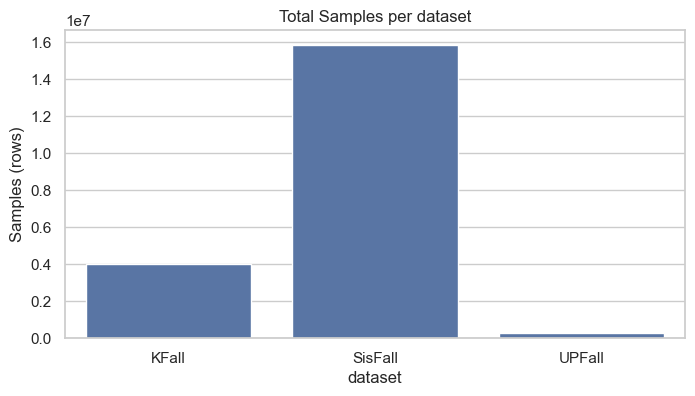

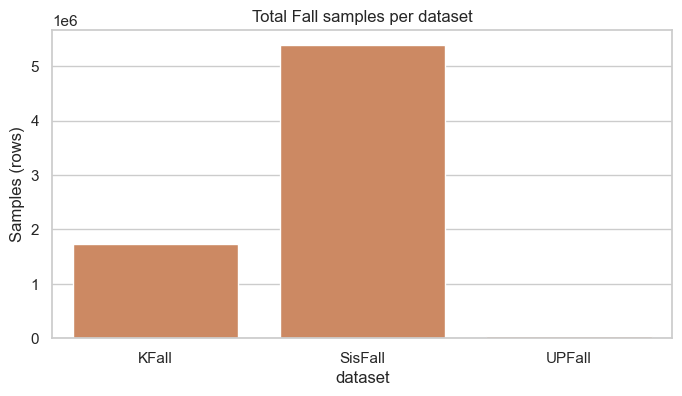

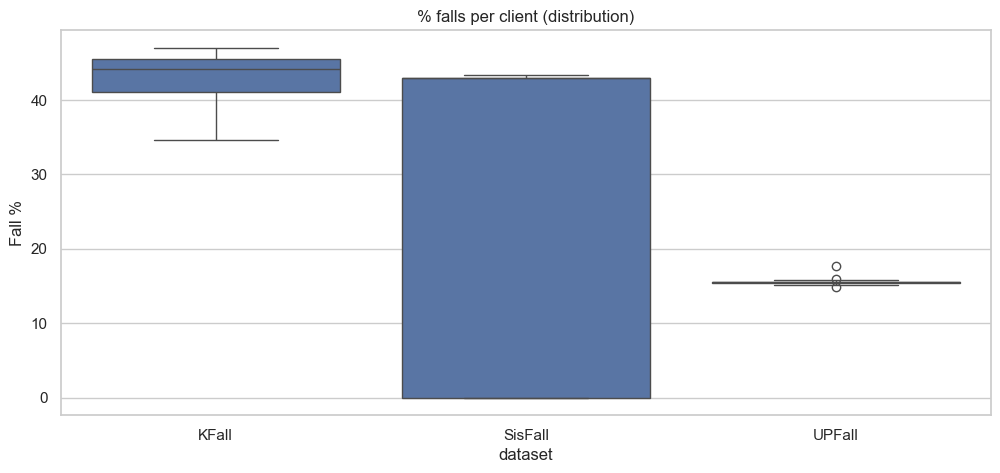

In [12]:
plt.figure(figsize=(8,4))
sns.barplot(data=base_totals, x="dataset", y="total_samples", color="#4c72b0")
plt.title("Total Samples per dataset")
plt.ylabel("Samples (rows)")
plt.show()

plt.figure(figsize=(8,4))
sns.barplot(data=base_totals, x="dataset", y="fall_samples", color="#dd8452")
plt.title("Total Fall samples per dataset")
plt.ylabel("Samples (rows)")
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(data=clients_table, x="dataset", y="fall_pct")
plt.title("% falls per client (distribution)")
plt.ylabel("Fall %")
plt.show()

In [13]:
kfall_files_balance = (
    kfall_meta.groupby(["client","category"])
             .size()
             .unstack(fill_value=0)
             .reset_index()
)
kfall_files_balance["dataset"] = "KFall"

sis_files_balance = (
    sis_meta.groupby(["client","category"])
            .size()
            .unstack(fill_value=0)
            .reset_index()
)
sis_files_balance["dataset"] = "SisFall"

up_trials_balance = (
    up_trials.groupby(["Subject","category"])
            .size()
            .unstack(fill_value=0)
            .reset_index()
)
up_trials_balance["client"] = up_trials_balance["Subject"].astype(str)
up_trials_balance = up_trials_balance.drop(columns=["Subject"])
up_trials_balance["dataset"] = "UPFall"

files_balance = pd.concat([kfall_files_balance, sis_files_balance, up_trials_balance], ignore_index=True)
files_balance["Fall_pct_files"] = files_balance.get("Fall", 0) / (files_balance.get("Fall", 0) + files_balance.get("ADL", 0)) * 100
files_balance

category,client,ADL,Fall,dataset,Fall_pct_files
0,SA06,85,71,KFall,45.512821
1,SA07,85,65,KFall,43.333333
2,SA08,89,74,KFall,45.398773
3,SA09,78,75,KFall,49.019608
4,SA10,84,75,KFall,47.169811
...,...,...,...,...,...
82,13,18,15,UPFall,45.454545
83,14,18,15,UPFall,45.454545
84,15,18,15,UPFall,45.454545
85,16,18,15,UPFall,45.454545


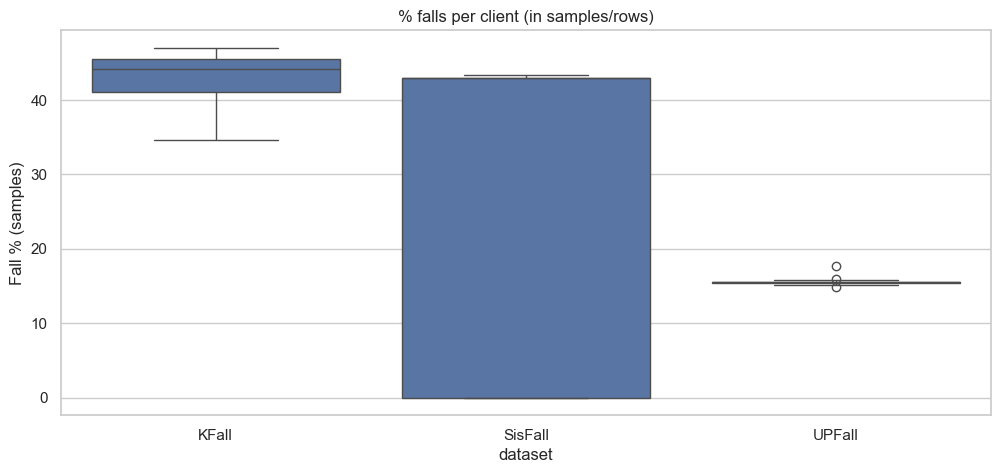

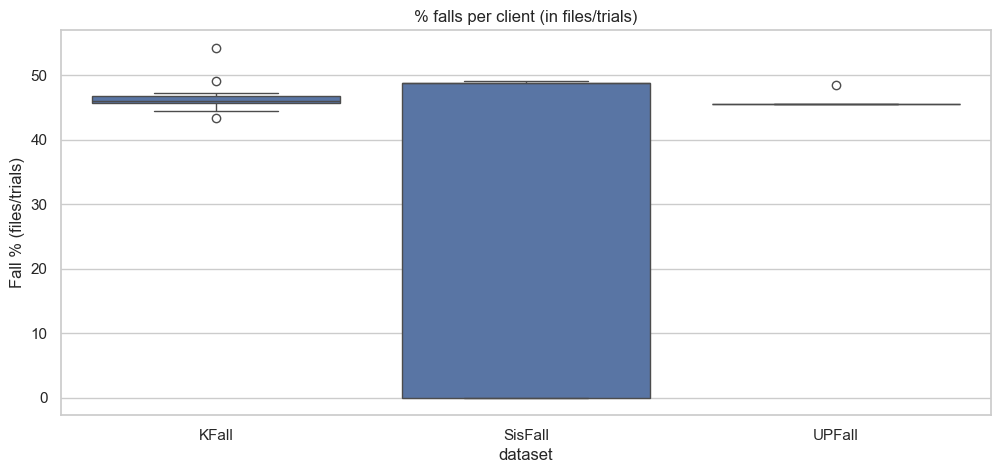

In [15]:
plt.figure(figsize=(12,5))
sns.boxplot(data=clients_table, x="dataset", y="fall_pct")
plt.title("% falls per client (in samples/rows)")
plt.ylabel("Fall % (samples)")
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(data=files_balance, x="dataset", y="Fall_pct_files")
plt.title("% falls per client (in files/trials)")
plt.ylabel("Fall % (files/trials)")
plt.show()

In [ ]:
kfall_cov = (
    kfall_meta.groupby(["client","category"])["task_id"]
             .nunique()
             .unstack(fill_value=0)
             .reset_index()
)
kfall_cov["dataset"] = "KFall"
kfall_cov = kfall_cov.rename(columns={"Fall":"n_fall_types", "ADL":"n_adl_types"})

sis_cov = (
    sis_meta.groupby(["client","category"])["activity"]
            .nunique()
            .unstack(fill_value=0)
            .reset_index()
)
sis_cov["dataset"] = "SisFall"
sis_cov = sis_cov.rename(columns={"Fall":"n_fall_types", "ADL":"n_adl_types"})

up_cov = (
    up_trials.groupby(["client","category"])["Activity"]
            .nunique()
            .unstack(fill_value=0)
            .reset_index()
)
up_cov["dataset"] = "UPFall"
up_cov = up_cov.rename(columns={"Fall":"n_fall_types", "ADL":"n_adl_types"})

coverage = pd.concat([kfall_cov, sis_cov, up_cov], ignore_index=True)
coverage

category,client,n_adl_types,n_fall_types,dataset
0,SA06,21,15,KFall
1,SA07,21,15,KFall
2,SA08,21,15,KFall
3,SA09,20,15,KFall
4,SA10,21,15,KFall
...,...,...,...,...
82,5,6,5,UPFall
83,6,6,5,UPFall
84,7,6,5,UPFall
85,8,6,5,UPFall


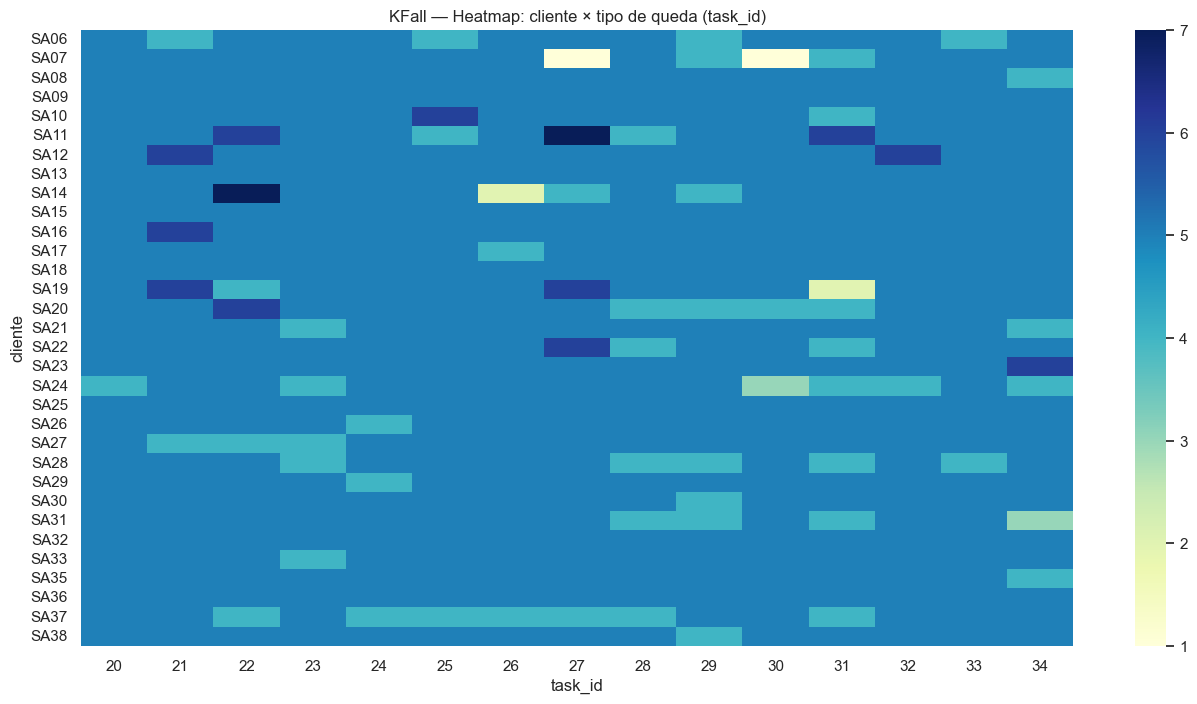

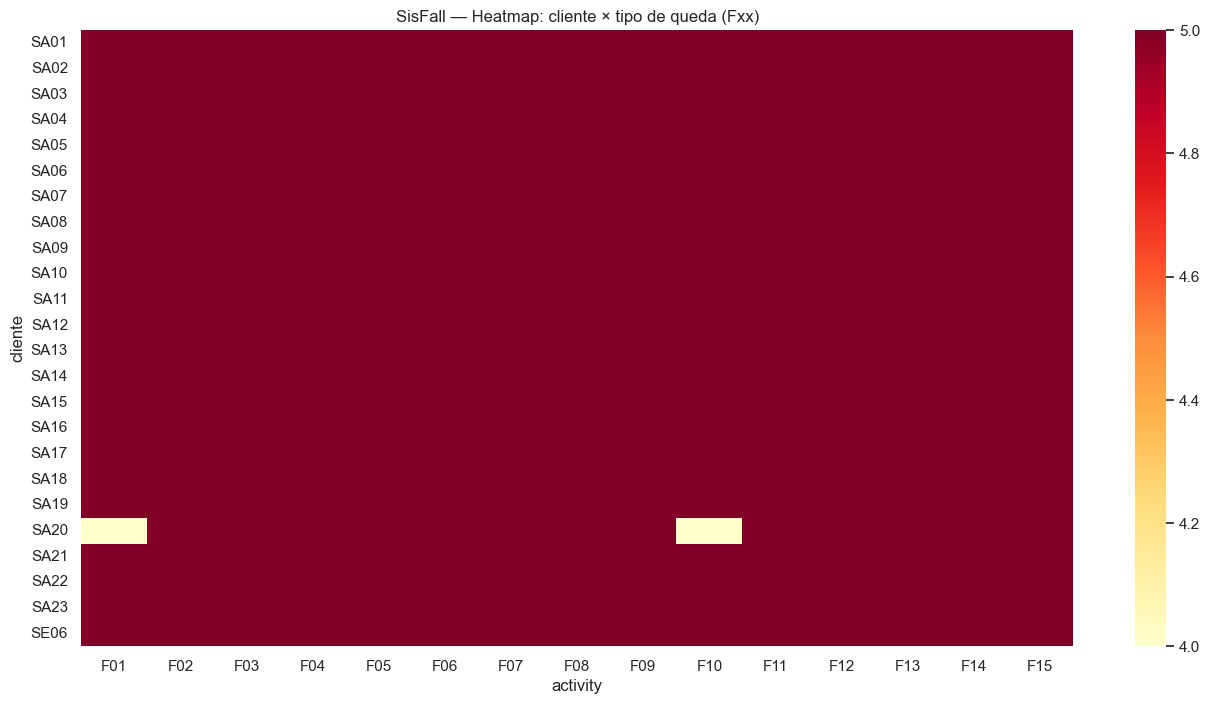

Text(92.25, 0.5, 'cliente')

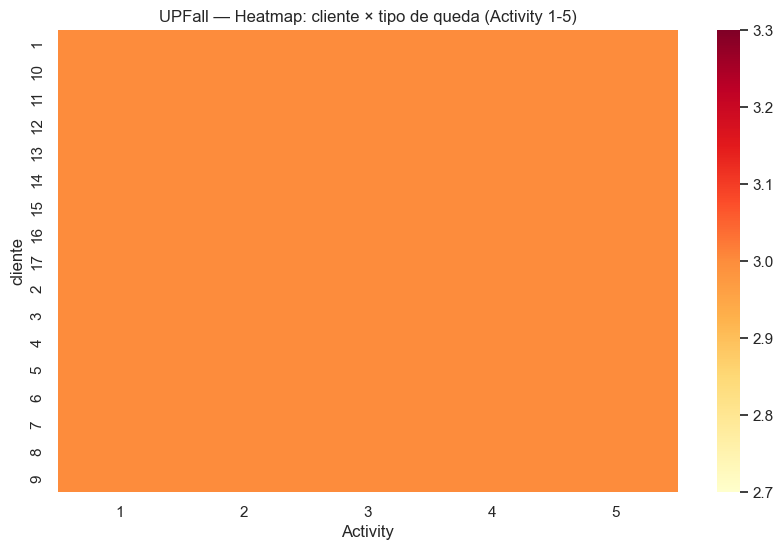

In [17]:
kf_fall_heat = (
    kfall_meta[kfall_meta["category"]=="Fall"]
      .groupby(["client","task_id"])
      .size()
      .unstack(fill_value=0)
)

plt.figure(figsize=(16,8))
sns.heatmap(kf_fall_heat, cmap="YlGnBu")
plt.title("KFall — Heatmap: cliente × tipo de queda (task_id)")
plt.xlabel("task_id")
plt.ylabel("cliente")
plt.show()

sf_fall_heat = (
    sis_meta[sis_meta["category"]=="Fall"]
      .groupby(["client","activity"])
      .size()
      .unstack(fill_value=0)
)

plt.figure(figsize=(16,8))
sns.heatmap(sf_fall_heat, cmap="YlOrRd")
plt.title("SisFall — Heatmap: cliente × tipo de queda (Fxx)")
plt.xlabel("activity")
plt.ylabel("cliente")
plt.show()

up_fall_heat = (
    up_trials[up_trials["category"]=="Fall"]
      .groupby(["client","Activity"])
      .size()
      .unstack(fill_value=0)
)

plt.figure(figsize=(10,6))
sns.heatmap(up_fall_heat, cmap="YlOrRd")
plt.title("UPFall — Heatmap: cliente × tipo de queda (Activity 1-5)")
plt.xlabel("Activity")
plt.ylabel("cliente")